Carregando datasets...
Found 1340 files belonging to 2 classes.
Using 1072 files for training.
Found 1340 files belonging to 2 classes.
Using 268 files for validation.
Montando o modelo...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Iniciando treinamento...
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 995ms/step - accuracy: 0.4328 - loss: 1.0424 - val_accuracy: 0.4813 - val_loss: 0.7996
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 774ms/step - accuracy: 0.5149 - loss: 0.8006 - val_accuracy: 0.6381 - val_loss: 0.6565
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 778ms/step - accuracy: 0.6287 - loss: 0.6815 - val_accuracy: 0.7276 - val_loss: 0.5477
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 763ms/step - accuracy: 0.7220 - loss: 0.5629 - val_accuracy: 0.7948 - val_loss: 0.4680
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 761ms/step - accuracy: 0.7761 - loss: 0.4991 - val_accuracy: 0.8470 - val_loss: 0.4058


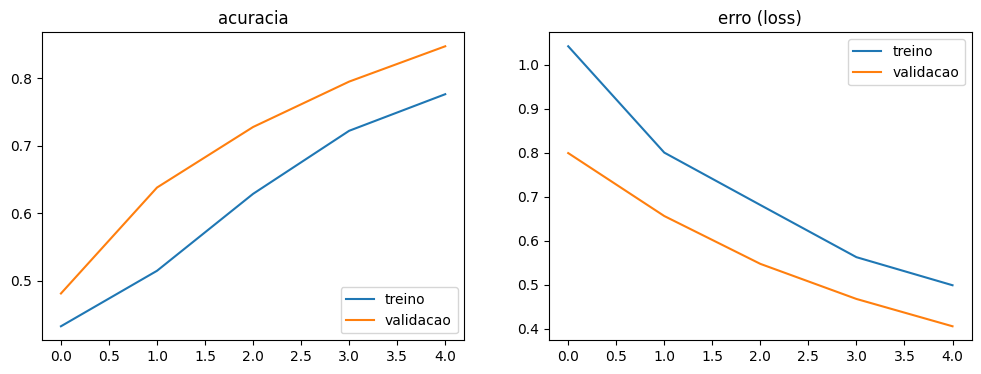

In [6]:
!wget -qO flower_photos.tgz https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xf flower_photos.tgz

import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt

data_dir = './flower_photos'

base_dir = './meu_dataset_binario'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.makedirs(os.path.join(base_dir, 'roses'))
os.makedirs(os.path.join(base_dir, 'sunflowers'))

# separando so as rosas e girassois pras minhas classes
for img in os.listdir(os.path.join(data_dir, 'roses')):
    shutil.copy(os.path.join(data_dir, 'roses', img), os.path.join(base_dir, 'roses', img))

for img in os.listdir(os.path.join(data_dir, 'sunflowers')):
    shutil.copy(os.path.join(data_dir, 'sunflowers', img), os.path.join(base_dir, 'sunflowers', img))

# definindo tamanho da imagem e do lote
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

print("Carregando datasets...")
# carregando meu dataset de treino (80% dos dados)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

# carregando o dataset de validacao (20% dos dados)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

# otimizando a leitura dos dados em memoria
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Montando o modelo...")
# puxando o modelo base mobilenetv2 sem a ultima camada
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# congelo os pesos originais pra não treinar tudo do zero
base_model.trainable = False

# montando meu proprio classificador no topo
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# compilando o modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

print("Iniciando treinamento...")
# rodando o treinamento por 5 epocas
history = model.fit(train_dataset, epochs=5, validation_data=validation_dataset)

# separando os resultados pra plotar
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# plotando os graficos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='treino')
plt.plot(val_acc, label='validacao')
plt.legend(loc='lower right')
plt.title('acuracia')

plt.subplot(1, 2, 2)
plt.plot(loss, label='treino')
plt.plot(val_loss, label='validacao')
plt.legend(loc='upper right')
plt.title('erro (loss)')
plt.show()